# Shamir's Secret Sharing Scheme On Images



### Lagrange Interpolation & Polynomial Notes

- Polynomial used: f(x) = a_0 + a_1 x + a_2 x^2 + ... + a_{k-1} x^{k-1}
- For threshold k the polynomial degree is k-1; a_0 is the secret (f(0)).

- Lagrange basis at 0 (given k shares (x_i, y_i)):

  For each i:

  numerator = Π_{j ≠ i} (0 - x_j) = Π_{j ≠ i} (-x_j)

  denominator = Π_{j ≠ i} (x_i - x_j)

  L_i(0) = numerator * denominator^{-1} (mod p)

- Reconstruction: secret = Σ_i y_i * L_i(0) (mod p).

Notes: All operations are performed in the finite field GF(p). The denominator requires a modular inverse, so arithmetic must be over a field (hence p is chosen prime in this notebook).

### Importing Libraries & Initializing Prime Value

In [13]:
import numpy as np 
import matplotlib.pyplot as plt
from PIL import Image # for image handling
import secrets # for generating secure random numbers

# prime > 255 for byte arithmetic
PRIME = 257


### Helper Function : Mod Inverse (EEA)

In [14]:
def mod_inverse(a, m=PRIME):
    def egcd(a, b):
        if a == 0: return (b, 0, 1)
        g, x1, y1 = egcd(b % a, a)
        return (g, y1 - (b // a) * x1, x1)
    g, x, _ = egcd(a % m, m)
    if g != 1:
        raise ValueError('No modular inverse')
    return x % m

### Shamir Secret Sharing On A Single Scalar Secret

#### Function: secrets.randbelow(x)

##### Generates a secure random integer in the range 0 to x - 1.

We use this instead of `random.randint` because Shamir secret sharing needs unpredictable coefficients. `secrets.randbelow()` is designed for cryptographic randomness, so the shares are harder to predict.

In this notebook, it is used to pick the random polynomial coefficients for each share.

For a threshold of `k`, the polynomial has `k` terms total: one constant term plus `k - 1` random terms.
So the polynomial degree is `k - 1`, not `k` or `k + 1`.

In [20]:


class ShamirsSecretSharing:

    # Initialializing k, n and p values for the class 
    def __init__(self, k, n, prime=PRIME):
        if k > n or k < 2: 
            raise ValueError('Invalid (k,n)')
        if n > prime - 1: 
            raise ValueError('n too large for prime')
        self.k, self.n, self.p = k, n, prime
    
    # Splits scalar secret s into n shares, need k to reconstruct
    def split_secret(self, s):
        s = int(s) % self.p # Make sure secret is in field (modulo p)
        coeffs = [s] + [secrets.randbelow(self.p - 1) + 1 for _ in range(self.k - 1)]
        shares = []
        # Note: Simple convention of taking x = 1,2,...,n for shares. Could be any distinct nonzero values in field.

        # x cannot be 0! (secret f(0) itself! and would break reconstruction)
        for x in range(1, self.n + 1):
            y = 0
            for power, c in enumerate(coeffs):
                y = (y + c * pow(x, power, self.p)) % self.p
            shares.append((x, y))
        return shares

    def reconstruct_secret(self, shares):
        # Try commenting this out and checking if secret is recovered by < k numbers! 
        if len(shares) < self.k: 
            raise ValueError('Need >= k shares')
            return None
        secret = 0
        m = self.p
        for i, (xi, yi) in enumerate(shares):
            # Initialize numerator and denominator for Lagrange basis polynomial
            num, den = 1, 1
            for j, (xj, _) in enumerate(shares):
                if i == j: continue
                num = (num * (-xj)) % m
                den = (den * (xi - xj)) % m
            li0 = (num * mod_inverse(den, m)) % m
            secret = (secret + yi * li0) % m
        return int(secret % 256)

In [22]:
print("Enter a secret (0-255): ")
secret = int(input())
print("Enter k: ")
k = int(input())
print("Enter n: ")
n = int(input())

print("Secret Sharing Parameters:")
print(f"secret = {secret}, prime = {PRIME}")
print(f"k = {k}, n = {n}")

# Create instance of Shamir's Secret Sharing
sss = ShamirsSecretSharing(k, n)

# Create shares 
shares = sss.split_secret(secret)
print(f"Shares (x,y): {shares}")

# Reconstruct secret from first <k shares (Not possible to recover value)
# recovered_false = sss.reconstruct_secret(shares[:k-1])
# print(f"Recovered secret with {k-1} shares: {recovered_false}")

# Can recover using k shares
print("Enter which shares to use for reconstruction (1-based indices, space separated): ")
share_indices = list(map(int, input().split()))
print("Selected shares for reconstruction:")
for i, (x, y) in enumerate(shares):
    if i + 1 in share_indices:
        print(f"  Share {i + 1}: ({x}, {y})")
selected_shares = [shares[i-1] for i in share_indices]
recovered_true = sss.reconstruct_secret(selected_shares)
print(f"Recovered secret with {k} shares: {recovered_true}")


Enter a secret (0-255): 
Enter k: 
Enter n: 
Secret Sharing Parameters:
secret = 192, prime = 257
k = 4, n = 10
Shares (x,y): [(1, 151), (2, 105), (3, 177), (4, 233), (5, 139), (6, 18), (7, 250), (8, 187), (9, 209), (10, 182)]
Enter which shares to use for reconstruction (1-based indices, space separated): 
Selected shares for reconstruction:
  Share 1: (1, 151)
  Share 2: (2, 105)
  Share 6: (6, 18)
  Share 9: (9, 209)
Recovered secret with 4 shares: 192


### Using SSS on Images

In [17]:
class ImageSSS:
    def __init__(self, k, n, prime=PRIME):
        self.sss = ShamirsSecretSharing(k, n, prime)
        self.k = k
        self.n = n

    def split_image(self, img):
        flat = img.flatten()
        print(flat)
        shares = [np.zeros_like(flat, dtype=np.uint16) for _ in range(self.n)]
        for i, v in enumerate(flat):
            ps = self.sss.split_secret(int(v))
            for si, (_, y) in enumerate(ps):
                shares[si][i] = y
        shape = img.shape
        return np.arange(1, self.n + 1), [s.reshape(shape) for s in shares], shape

    def reconstruct_image(self, x_coords, shares_arr, shape):
        flat_out = np.zeros(shape[0] * shape[1], dtype=np.uint8)
        for idx in range(flat_out.size):
            pixel_shares = [(int(x_coords[i]), int(sh.flat[idx])) for i, sh in enumerate(shares_arr)]
            flat_out[idx] = self.sss.reconstruct_secret(pixel_shares)
        return flat_out.reshape(shape)

STEP 1: ORIGINAL IMAGE
Image shape: (833, 625)
Image dtype: uint8
Pixel value range: [3, 255]

Original Pixel Matrix (first 10x10 subset):
[[74 72 73 78 81 79 78 79 83 76]
 [73 71 73 78 80 77 75 75 86 78]
 [71 70 72 77 79 76 73 73 78 76]
 [72 69 70 74 76 75 74 76 71 78]
 [73 69 67 71 74 75 77 81 81 84]
 [73 68 67 70 73 74 77 81 91 83]
 [71 68 67 71 73 72 73 75 82 77]
 [69 67 68 73 74 71 68 68 69 75]
 [66 64 64 65 68 70 69 67 71 75]
 [69 68 67 69 72 75 75 75 70 72]]


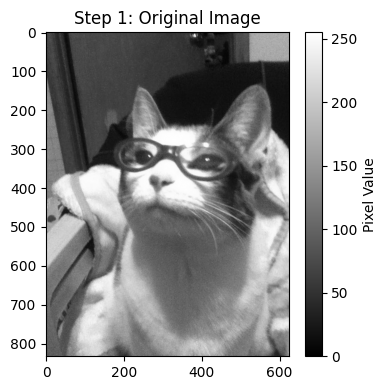

STEP 2: FLATTEN IMAGE
Flattened shape: (520625,)
Total pixels: 520625
First 20 flattened pixel values: [74 72 73 78 81 79 78 79 83 76 68 65 70 75 72 64 54 64 67 59]
STEP 3: INITIALIZE EMPTY SHARES
Threshold scheme: k=3, n=5
Need at least 3 of 5 shares to reconstruct

Initialized 5 empty shares, each of shape: (520625,)
Each share will contain values in range [0, 256] (finite field GF(257))

Share 1 (before splitting, first 20 values):
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
STEP 4: SPLIT PIXELS - COMPUTING SHARES
Pixel 0 (value=74): shares = [(1, 177), (2, 80), (3, 40), (4, 57), (5, 131)]
Pixel 1 (value=72): shares = [(1, 155), (2, 169), (3, 114), (4, 247), (5, 54)]
Pixel 2 (value=73): shares = [(1, 92), (2, 150), (3, 247), (4, 126), (5, 44)]
Pixel 3 (value=78): shares = [(1, 221), (2, 233), (3, 114), (4, 121), (5, 254)]
Pixel 4 (value=81): shares = [(1, 97), (2, 254), (3, 38), (4, 220), (5, 29)]
Pixel 520624 (value=155): shares = [(1, 18), (2, 147), (3, 28), (4, 175), (5, 74)]

Resh

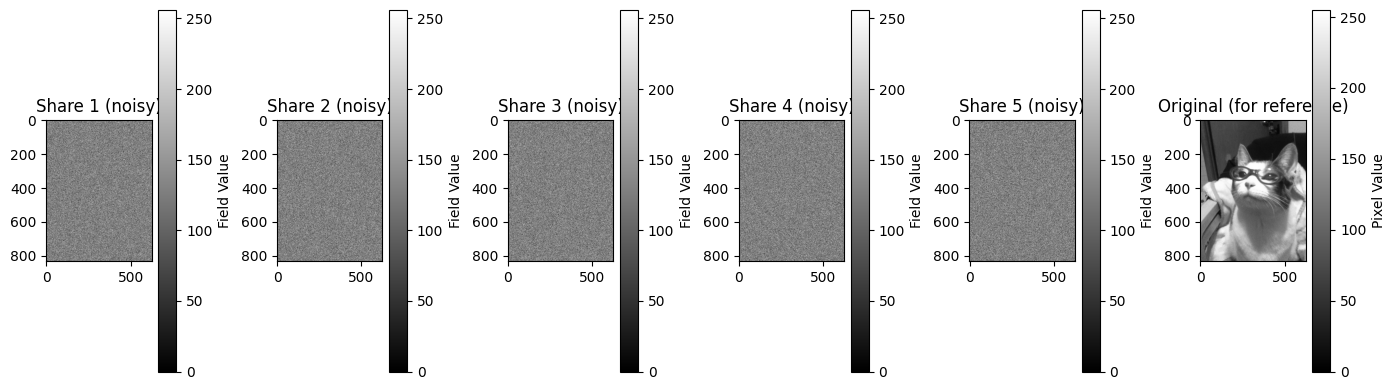

STEP 6: RECONSTRUCTION READY
Share x-coordinates (evaluation points): [1 2 3 4 5]
To reconstruct, we need at least k=3 shares
Display showing first k=3 shares being used for reconstruction...

Reconstruction from shares [np.int64(1), np.int64(2), np.int64(3)]: MATCH = True


/var/folders/zj/5gdxx71d3p53ch83fydgddvh0000gn/T/ipykernel_37599/318117324.py:104: UserWarning: tight_layout not applied: number of columns in subplot specifications must be multiples of one another.
  plt.tight_layout()


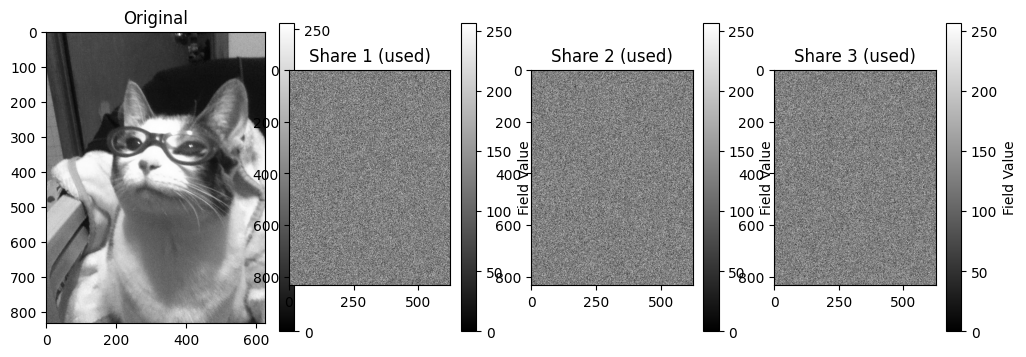


Reconstruction from shares [1, 2, 3]: True


In [18]:
from pathlib import Path
p = Path('.') / 'cat.jpeg'
if p.exists():
    pil = Image.open(p).convert('L')
    img = np.array(pil, dtype=np.uint8)
else:
    def make_test():
        a = np.zeros((100, 100), dtype=np.uint8)
        for i in range(100):
            a[i] = int(50 + 150 * i / 100)  # pixel values from 50 to 200
        return a
    img = make_test()


print("STEP 1: ORIGINAL IMAGE")

print(f"Image shape: {img.shape}")
print(f"Image dtype: {img.dtype}")
print(f"Pixel value range: [{img.min()}, {img.max()}]")
print("\nOriginal Pixel Matrix (first 10x10 subset):")
print(img[:10, :10])

# Visualize original image
plt.figure(figsize=(4, 4))
plt.imshow(img, cmap='gray', vmin=0, vmax=255)
plt.title('Step 1: Original Image')
plt.colorbar(label='Pixel Value')
plt.tight_layout()
plt.show()

print("STEP 2: FLATTEN IMAGE")

flat = img.flatten()
print(f"Flattened shape: {flat.shape}")
print(f"Total pixels: {flat.size}")
print(f"First 20 flattened pixel values: {flat[:20]}")

k, n = 3, 5  # (2,3) threshold scheme

print("STEP 3: INITIALIZE EMPTY SHARES")
print(f"Threshold scheme: k={k}, n={n}")
print(f"Need at least {k} of {n} shares to reconstruct")

iss = ImageSSS(k, n)
shares = [np.zeros_like(flat, dtype=np.uint16) for _ in range(n)]
print(f"\nInitialized {n} empty shares, each of shape: {shares[0].shape}")
print(f"Each share will contain values in range [0, {PRIME-1}] (finite field GF({PRIME}))")

# Show one empty share (before splitting)
print(f"\nShare 1 (before splitting, first 20 values):\n{shares[0][:20]}")


print("STEP 4: SPLIT PIXELS - COMPUTING SHARES")
for i, v in enumerate(flat):
    ps = iss.sss.split_secret(int(v))
    for si, (_, y) in enumerate(ps):
        shares[si][i] = y
    if i < 5 or i == flat.size - 1:
        print(f"Pixel {i} (value={v}): shares = {ps}")

# Reshape shares back to image dimensions
shares_img = [s.reshape(img.shape) for s in shares]
print(f"\nReshaped each share back to image dimensions: {shares_img[0].shape}")


print("STEP 5: VISUALIZE ALL NOISY SHARES")
fig = plt.figure(figsize=(14, 4))
for i in range(n):
    print(f"Share {i+1} statistics: min={shares_img[i].min()}, max={shares_img[i].max()}, mean={shares_img[i].mean():.1f}")
    ax = plt.subplot(1, n+1, i+1)
    plt.imshow(shares_img[i], cmap='gray', vmin=0, vmax=PRIME-1)
    plt.title(f'Share {i+1} (noisy)')
    plt.colorbar(label='Field Value')
ax = plt.subplot(1, n+1, n+1)
plt.imshow(img, cmap='gray', vmin=0, vmax=255)
plt.title('Original (for reference)')
plt.colorbar(label='Pixel Value')
plt.tight_layout()
plt.show()


print("STEP 6: RECONSTRUCTION READY")
x_coords = np.arange(1, n + 1)
print(f"Share x-coordinates (evaluation points): {x_coords}")
print(f"To reconstruct, we need at least k={k} shares")
print(f"Display showing first k={k} shares being used for reconstruction...")

# Reconstruct using first k shares automatically
rec = iss.reconstruct_image(x_coords[:k], shares_img[:k], img.shape)
match = np.array_equal(rec, img)
print(f"\nReconstruction from shares {list(x_coords[:k])}: MATCH = {match}")

# Show reconstruction result
fig = plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.imshow(img, cmap='gray', vmin=0, vmax=255)
plt.title('Original')
plt.colorbar(label='Pixel Value')
for i in range(k):
    plt.subplot(1, 4, i+2)
    plt.imshow(shares_img[i], cmap='gray', vmin=0, vmax=PRIME-1)
    plt.title(f'Share {i+1} (used)')
    plt.colorbar(label='Field Value')
plt.tight_layout()
plt.show()

print(f"\nReconstruction from shares {x_coords[:k].tolist()}: {match}")

In [19]:

print(f"Available shares: 1, 2, 3")
print("\nEnter share indices to use for reconstruction (space-separated):")
print("Example: '1 2' or '1 3' or '2 3'")

user_input = input().strip().split()
selected_indices = [int(idx) for idx in user_input]

# Validate input
if len(selected_indices) < k:
    print(f"\nERROR: You selected {len(selected_indices)} shares, but need at least k={k}")
    print(f"Try again with at least {k} shares")
else:
    print(f"\n✓ Selected shares: {selected_indices}")
    print(f"Using {len(selected_indices)} shares for reconstruction (need {k})")
    
    # Extract the selected shares and x-coordinates
    selected_shares_img = [shares_img[i-1] for i in selected_indices]
    selected_x_coords = np.array(selected_indices)
    
    # Reconstruct
    rec_custom = iss.reconstruct_image(selected_x_coords, selected_shares_img, img.shape)
    match_custom = np.array_equal(rec_custom, img)
    
    print(f"\nReconstruction Result: {'✓ PERFECT MATCH!' if match_custom else '❌ MISMATCH'}")
    print(f"Match = {match_custom}")
    
    # Visualize
    num_selected = len(selected_indices)
    fig = plt.figure(figsize=(4 * (num_selected + 2), 4))
    
    plt.subplot(1, num_selected + 2, 1)
    plt.imshow(img, cmap='gray', vmin=0, vmax=255)
    plt.title('Original Image')
    plt.colorbar(label='Pixel Value')
    
    for pos, share_idx in enumerate(selected_indices):
        plt.subplot(1, num_selected + 2, pos + 2)
        plt.imshow(shares_img[share_idx-1], cmap='gray', vmin=0, vmax=PRIME-1)
        plt.title(f'Share {share_idx} (selected)')
        plt.colorbar(label='Field Value')
    
    plt.subplot(1, num_selected + 2, num_selected + 2)
    plt.imshow(rec_custom, cmap='gray', vmin=0, vmax=255)
    plt.title(f'Reconstructed\n(from {num_selected} shares)')
    plt.colorbar(label='Pixel Value')
    
    plt.tight_layout()
    plt.show()

Available shares: 1, 2, 3

Enter share indices to use for reconstruction (space-separated):
Example: '1 2' or '1 3' or '2 3'

ERROR: You selected 1 shares, but need at least k=3
Try again with at least 3 shares


##### Link: https://cherie-dips.github.io/diptidhawade/blog/visual-secret-sharing